# Imports

In [1]:
# Instalar PyTorch con CUDA (primero, para evitar que sentence-transformers instale CPU)
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


# Dataset and Preprocessing

In [3]:
import gc
import pandas as pd

from datasets import load_dataset
from datasets import Dataset

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\Usuario\AppData\Local\Temp\pip-install-lxydl57f\pandas_5088885acae24cb7bbaee143a89dc663 C:\Users\Usuario\AppData\Local\Temp\pip-install-lxydl57f\pandas_5088885acae24cb7bbaee143a89dc663\.mesonpy-bw7f2jnh\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\Usuario\AppData\Local\Temp\pip-install-lxydl57f\pandas_5088885acae24cb7bbaee143a89dc663\.mesonpy-bw7f2jnh\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\Usuario\AppData\Local\Temp\

  Using cached pandas-2.2.2.tar.gz (4.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


In [4]:
dataset = load_dataset("imdb")
df_text_train = pd.DataFrame(dataset["train"])
df_text_test = pd.DataFrame(dataset["test"])

In [5]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [6]:
def build_prompt(review):

    prompt = f"""Review: {review}

Sentiment:"""

    return prompt


def build_full_text(review, label):

    sentiment = (
        "positive"
        if label == 1
        else "negative"
    )

    full_text = f"""Review: {review}

Sentiment: {sentiment}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):

    input_ids_list = []
    attention_masks_list = []
    labels_list = []
    true_labels_list = []

    for example in dataset:

        review = example["text"]
        label = example["label"]

        prompt = build_prompt(review)
        full_text = build_full_text(review, label)

        # =========================
        # TOKENIZACIÓN
        # =========================

        full = tokenizer(
            full_text,
            add_special_tokens=False
        )

        input_ids = full["input_ids"]

        # attention mask inicial
        attention_mask = [1] * len(input_ids)

        # =========================
        # LABELS (SIN prompt_len)
        # =========================

        labels = []

        # reconstruimos prompt tokenizado directamente dentro del full_text
        prompt_text = build_prompt(review)

        prompt_ids = tokenizer(
            prompt_text,
            add_special_tokens=False
        )["input_ids"]

        # ⚠️ no asumimos alineación por slicing, buscamos corte seguro por longitud
        prompt_len = len(prompt_ids)

        for i, tok in enumerate(input_ids):

            if i < prompt_len:
                labels.append(-100)
            else:
                labels.append(tok)

        # =========================
        # PADDING / TRUNCATION UNIFORME
        # =========================

        if len(input_ids) > MAX_LENGTH:

            input_ids = input_ids[:MAX_LENGTH]
            attention_mask = attention_mask[:MAX_LENGTH]
            labels = labels[:MAX_LENGTH]

        else:

            pad_len = MAX_LENGTH - len(input_ids)

            input_ids += [tokenizer.pad_token_id] * pad_len
            attention_mask += [0] * pad_len
            labels += [-100] * pad_len

        # =========================
        # TRUE LABEL EXPLÍCITO
        # =========================

        true_label = "positive" if label == 1 else "negative"

        # =========================
        # STORE
        # =========================

        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)
        labels_list.append(labels)
        true_labels_list.append(true_label)

    return Dataset.from_dict({
        "input_ids": input_ids_list,
        "attention_mask": attention_masks_list,
        "labels": labels_list,
        "true_label": true_labels_list
    })

In [7]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [8]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [9]:
split = dataset["train"].train_test_split(
    test_size=0.1,
    seed=42
)

train_raw = split["train"]
val_raw = split["test"]
test_raw = dataset["test"]

In [10]:
# Reviews exceeding model context are removed from the dataset.

filtered_train = train_raw.filter(
    fits_model
)

filtered_val = val_raw.filter(
    fits_model
)

filtered_test = test_raw.filter(
    fits_model
)

In [11]:
train_dataset = preprocess_dataset(filtered_train, tokenizer)
val_dataset = preprocess_dataset(filtered_val, tokenizer)
test_dataset = preprocess_dataset(filtered_test, tokenizer)

In [12]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

val_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

# Student definition

In [13]:
# LLM Model download
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3269.82it/s]


In [14]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [15]:
teacher_model.load_state_dict(
      torch.load(
          "../checkpoints/imdb/best_teacher_model.pt",
          map_location=device
      )
  )

<All keys matched successfully>

In [16]:
teacher_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [17]:
from transformers import AutoConfig

# cargar config del teacher
config = AutoConfig.from_pretrained(MODEL_NAME)

# reducir capas si querés pure_student 11 capas
config.num_hidden_layers = 11

# crear pure_student RANDOM
pure_student_model = AutoModelForCausalLM.from_config(config)

In [18]:
pure_student_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

# Student training

In [19]:
BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
def save_checkpoint(model, optimizer, epoch, global_step, path="checkpoint.pt"):

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "global_step": global_step
        },
        path
    )

def load_checkpoint(model, optimizer, path="checkpoint.pt"):

    ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    return ckpt["epoch"], ckpt["global_step"]

In [21]:
# =========================
# CONFIG DISTILLATION
# =========================
temperature = 2.0
alpha = 0
lr = 1e-4

EPOCHS = 3

teacher_model.eval()
pure_student_model.train()

for p in teacher_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    pure_student_model.parameters(),
    lr=lr
)

In [22]:
best_val_loss = float("inf")
eval_every = 1000
save_every = 2000
start_epoch = 0
global_step = 0
max_val_steps = 100

In [23]:
try:
    start_epoch, global_step = load_checkpoint(
        pure_student_model,
        optimizer,
        "../checkpoints/imdb/pure_student_checkpoint.pt"
    )

    print(f"[RESUME] Epoch {start_epoch} | Global step {global_step}")

except:
    print("[START] Training from scratch")


# =========================
# INIT LOSS
# =========================

pure_student_model.eval()

with torch.no_grad():
    batch = next(iter(train_loader))

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    teacher_outputs = teacher_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    pure_student_outputs = pure_student_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    ce_loss = pure_student_outputs.loss

    kd_loss = F.kl_div(
        F.log_softmax(
            pure_student_outputs.logits / temperature,
            dim=-1
        ),
        F.softmax(
            teacher_outputs.logits / temperature,
            dim=-1
        ),
        reduction="batchmean"
    ) * (temperature ** 2)

    init_loss = (
        alpha * ce_loss
        + (1 - alpha) * kd_loss
    )

    print(
        f"[INIT LOSS] "
        f"Total={init_loss.item():.4f} | "
        f"CE={ce_loss.item():.4f} | "
        f"KD={kd_loss.item():.4f}"
    )

pure_student_model.train()

# =========================
# TRAINING
# =========================

for epoch in range(start_epoch, EPOCHS):

    pure_student_model.train()

    total_loss = 0
    total_ce = 0
    total_kd = 0

    for step, batch in enumerate(train_loader):

        global_step += 1

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # =========================
        # TEACHER
        # =========================

        with torch.no_grad():

            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # =========================
        # pure_student
        # =========================

        pure_student_outputs = pure_student_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        ce_loss = pure_student_outputs.loss

        kd_loss = F.kl_div(
            F.log_softmax(
                pure_student_outputs.logits / temperature,
                dim=-1
            ),
            F.softmax(
                teacher_outputs.logits / temperature,
                dim=-1
            ),
            reduction="batchmean"
        ) * (temperature ** 2)

        loss = (
            alpha * ce_loss
            + (1 - alpha) * kd_loss
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_kd += kd_loss.item()

        if global_step % 50 == 0:

            avg_loss = total_loss / (step + 1)
            avg_ce = total_ce / (step + 1)
            avg_kd = total_kd / (step + 1)

            print(
                f"Epoch {epoch} | "
                f"Step {step} | "
                f"Global {global_step} | "
                f"Loss {avg_loss:.4f} | "
                f"CE {avg_ce:.4f} | "
                f"KD {avg_kd:.4f}"
            )

        # =========================
        # VALIDATION
        # =========================

        if global_step % eval_every == 0:

            pure_student_model.eval()

            val_loss = 0
            val_steps = 0

            with torch.no_grad():

                for val_batch in val_loader:

                    val_steps += 1

                    input_ids = (
                        val_batch["input_ids"]
                        .to(device)
                    )

                    attention_mask = (
                        val_batch["attention_mask"]
                        .to(device)
                    )

                    labels = (
                        val_batch["labels"]
                        .to(device)
                    )

                    teacher_outputs = teacher_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    pure_student_outputs = pure_student_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )

                    ce_loss = pure_student_outputs.loss

                    kd_loss = F.kl_div(
                        F.log_softmax(
                            pure_student_outputs.logits
                            / temperature,
                            dim=-1
                        ),
                        F.softmax(
                            teacher_outputs.logits
                            / temperature,
                            dim=-1
                        ),
                        reduction="batchmean"
                    ) * (temperature ** 2)

                    batch_loss = (
                        alpha * ce_loss
                        + (1 - alpha) * kd_loss
                    )

                    val_loss += batch_loss.item()

                    if val_steps >= max_val_steps:
                        break

            val_loss /= val_steps

            print(
                f"\n[VAL LOSS] "
                f"{val_loss:.4f}\n"
            )

            # =========================
            # BEST MODEL
            # =========================

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                patience_counter = 0

                torch.save(
                    pure_student_model.state_dict(),
                    "../checkpoints/imdb/best_pure_student_model.pt"
                )

                print("[BEST MODEL SAVED]")

            else:
                patience_counter += 1

            # =========================
            # CHECKPOINT
            # =========================

            save_checkpoint(
                pure_student_model,
                optimizer,
                epoch,
                global_step,
                "../checkpoints/imdb/pure_student_checkpoint.pt"
            )


        # =========================
        # CLEANUP
        # =========================

        del (
            input_ids,
            attention_mask,
            labels,
            teacher_outputs,
            pure_student_outputs,
            ce_loss,
            kd_loss,
            loss
        )

    gc.collect()

[START] Training from scratch
[INIT LOSS] Total=44288.0000 | CE=10.7609 | KD=44288.0000
Epoch 0 | Step 49 | Global 50 | Loss 7570.2400 | CE 15.6481 | KD 7570.2400
Epoch 0 | Step 99 | Global 100 | Loss 5518.4000 | CE 11.2658 | KD 5518.4000
Epoch 0 | Step 149 | Global 150 | Loss 4715.3067 | CE 9.0881 | KD 4715.3067
Epoch 0 | Step 199 | Global 200 | Loss 4190.1200 | CE 7.8070 | KD 4190.1200
Epoch 0 | Step 249 | Global 250 | Loss 3977.9520 | CE 6.9951 | KD 3977.9520
Epoch 0 | Step 299 | Global 300 | Loss 3769.4933 | CE 6.4482 | KD 3769.4933
Epoch 0 | Step 349 | Global 350 | Loss 3641.7371 | CE 6.0830 | KD 3641.7371
Epoch 0 | Step 399 | Global 400 | Loss 3529.3200 | CE 5.8899 | KD 3529.3200
Epoch 0 | Step 449 | Global 450 | Loss 3447.4844 | CE 5.7402 | KD 3447.4844
Epoch 0 | Step 499 | Global 500 | Loss 3332.0640 | CE 5.5091 | KD 3332.0640
Epoch 0 | Step 549 | Global 550 | Loss 3252.2473 | CE 5.3425 | KD 3252.2473
Epoch 0 | Step 599 | Global 600 | Loss 3239.4467 | CE 5.2309 | KD 3239.4467
E

In [24]:
pure_student_model.load_state_dict(
    torch.load(
        "../checkpoints/imdb/best_pure_student_model.pt",
        map_location=device
    )
)

<All keys matched successfully>

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =========================
# TARGET TOKENS
# =========================

positive_id = tokenizer.encode(
    " positive",
    add_special_tokens=False
)[0]

negative_id = tokenizer.encode(
    " negative",
    add_special_tokens=False
)[0]

# =========================
# TEST EVALUATION
# =========================

teacher_model.eval()
pure_student_model.eval()

y_true = []
y_pred_pure_student = []

kl_total = 0.0
n_batches = 0

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        true_labels = batch["true_label"]

        # =========================
        # TEACHER
        # =========================
        teacher_outputs = teacher_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # =========================
        # pure_student
        # =========================
        pure_student_outputs = pure_student_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # =========================
        # POSICIÓN CORRECTA
        # =========================
        last_idx = attention_mask.sum(dim=1) - 2

        teacher_logits = teacher_outputs.logits[
            torch.arange(input_ids.size(0), device=device),
            last_idx
        ]

        pure_student_logits = pure_student_outputs.logits[
            torch.arange(input_ids.size(0), device=device),
            last_idx
        ]

        # =========================
        # CLASSIFICATION (pure_student)
        # =========================
        pure_student_positive = pure_student_logits[:, positive_id]
        pure_student_negative = pure_student_logits[:, negative_id]

        preds = pure_student_positive > pure_student_negative

        for p, t in zip(preds, true_labels):

            y_pred_pure_student.append(
                "positive" if p.item() else "negative"
            )
            y_true.append(t)

        # =========================
        # KL DIVERGENCE (pure_student vs teacher)
        # =========================

        T = 2.0  # podés usar el mismo temperature del training

        kl = F.kl_div(
            F.log_softmax(pure_student_logits / T, dim=-1),
            F.softmax(teacher_logits / T, dim=-1),
            reduction="batchmean"
        ) * (T ** 2)

        kl_total += kl.item()
        n_batches += 1

# =========================
# FINAL METRICS
# =========================

kl_avg = kl_total / n_batches

print("\n===== TEST RESULTS =====")
print("KL(pure_student || teacher):", kl_avg)

# =========================
# METRICS
# =========================

test_accuracy = accuracy_score(
    y_true,
    y_pred_pure_student
)

test_precision = precision_score(
    y_true,
    y_pred_pure_student,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred_pure_student,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred_pure_student,
    average="macro",
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred_pure_student,
    labels=[
        "positive",
        "negative"
    ]
)


===== TEST RESULTS =====
KL(pure_student || teacher): 0.6170156101532807


In [26]:
# =========================
# PRINT
# =========================

print("\n=========================")
print("[TEST RESULTS]")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print("=========================\n")

print("[CONFUSION MATRIX]")
print(cm)


[TEST RESULTS]
Accuracy : 0.7728
Precision: 0.7899
Recall   : 0.7727
F1 Score : 0.7693

[CONFUSION MATRIX]
[[ 8135  4360]
 [ 1320 11180]]


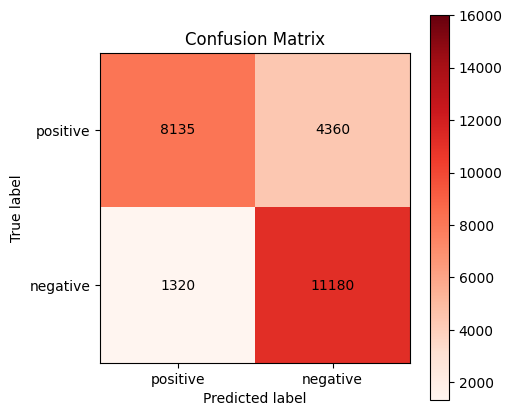

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(cm, cmap="Reds", vmax=16000)

# labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["positive", "negative"])
ax.set_yticklabels(["positive", "negative"])

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

# valores dentro de las celdas
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="black")

plt.colorbar(im)
plt.show()